In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/AmesHousing.csv")
print(df.head())
print("tail")
print(df.tail())

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

In [3]:
print("information")
print(df.info())
print("description")
print(df.describe())

information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  Ho

In [7]:
miss_val =df.isnull().sum()
print(miss_val[miss_val > 0])

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


In [8]:
drop_cols = ['Alley','Pool QC','Fence','Misc Feature','Fireplace Qu','Mas Vnr Type']
df.drop(columns=drop_cols,inplace=True)

In [10]:
miss_val =df.isnull().sum()
print(miss_val[miss_val > 0])

Lot Frontage      490
Mas Vnr Area       23
Bsmt Qual          80
Bsmt Cond          80
Bsmt Exposure      83
BsmtFin Type 1     80
BsmtFin SF 1        1
BsmtFin Type 2     81
BsmtFin SF 2        1
Bsmt Unf SF         1
Total Bsmt SF       1
Electrical          1
Bsmt Full Bath      2
Bsmt Half Bath      2
Garage Type       157
Garage Yr Blt     159
Garage Finish     159
Garage Cars         1
Garage Area         1
Garage Qual       159
Garage Cond       159
dtype: int64


In [11]:
cat_col = ['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2','Electrical','Garage Type','Garage Finish','Garage Qual','Garage Cond']
for col in cat_col:
  df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1126/1687089621.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [12]:
miss_val =df.isnull().sum()
print(miss_val[miss_val > 0])

Lot Frontage      490
Mas Vnr Area       23
BsmtFin SF 1        1
BsmtFin SF 2        1
Bsmt Unf SF         1
Total Bsmt SF       1
Bsmt Full Bath      2
Bsmt Half Bath      2
Garage Yr Blt     159
Garage Cars         1
Garage Area         1
dtype: int64


In [13]:
num_cols = ['Lot Frontage','Mas Vnr Area','BsmtFin SF 1','BsmtFin SF 2','Bsmt Unf SF','Total Bsmt SF','Bsmt Full Bath','Bsmt Half Bath','Garage Yr Blt','Garage Cars','Garage Area']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [14]:
miss_val =df.isnull().sum()
print(miss_val[miss_val > 0])

Series([], dtype: int64)


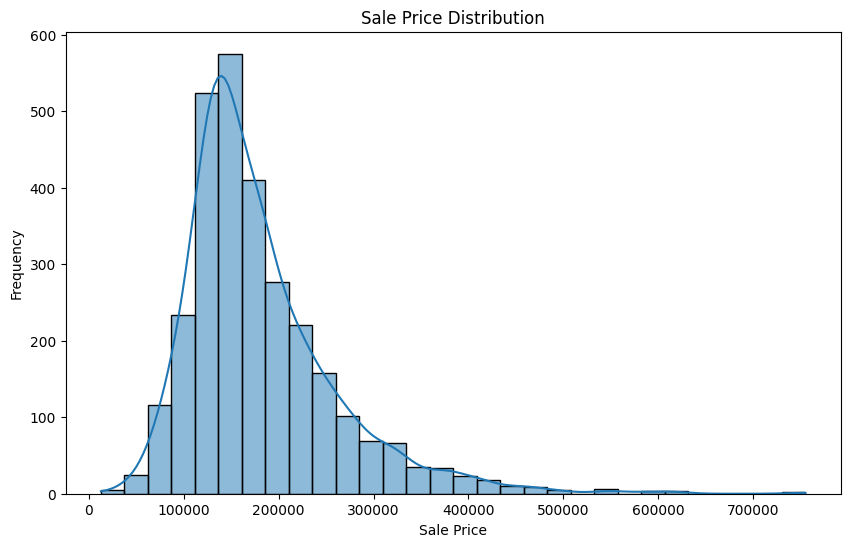

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title("Sale Price Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

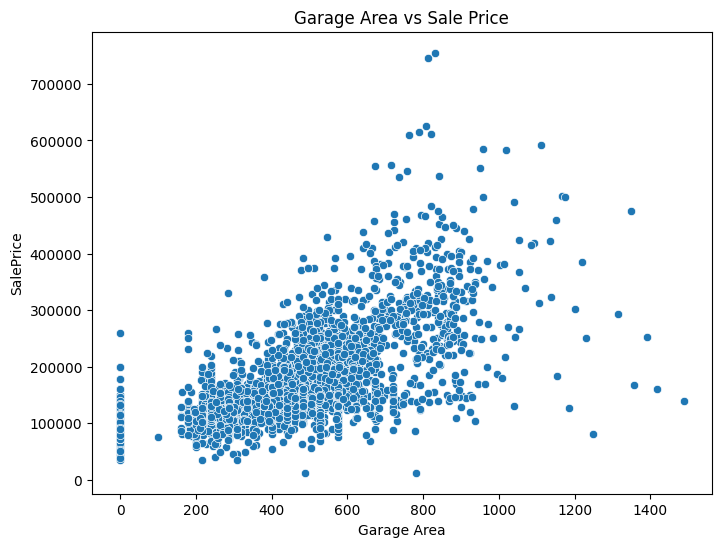

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Garage Area',y='SalePrice',data=df)
plt.title("Garage Area vs Sale Price")
plt.show()

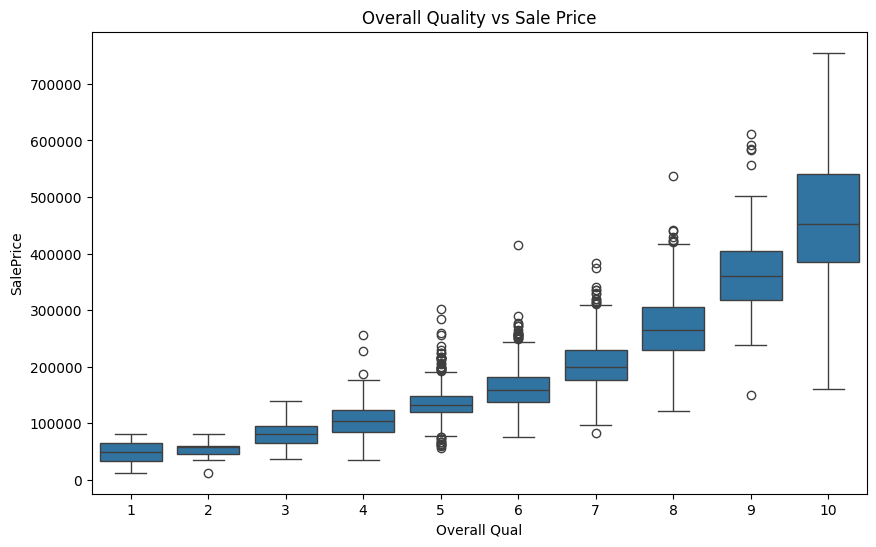

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Overall Qual',y='SalePrice',data=df)
plt.title("Overall Quality vs Sale Price")
plt.show()

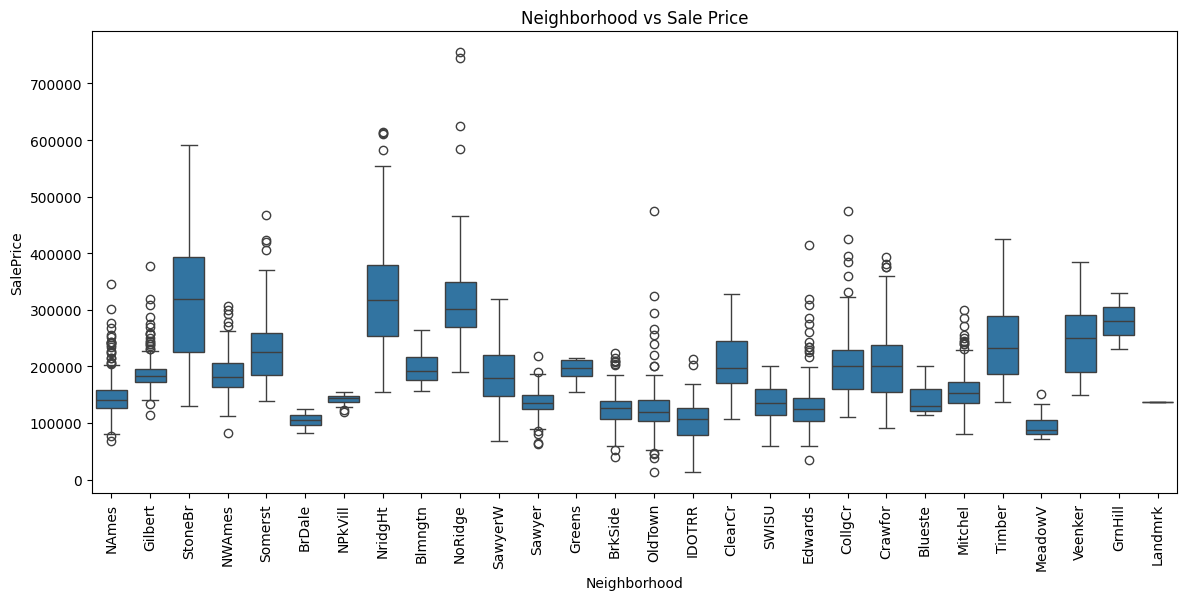

In [19]:
plt.figure(figsize=(14,6)),sns.boxplot(x='Neighborhood',y='SalePrice',data=df)
plt.xticks(rotation=90)
plt.title("Neighborhood vs Sale Price")
plt.show()

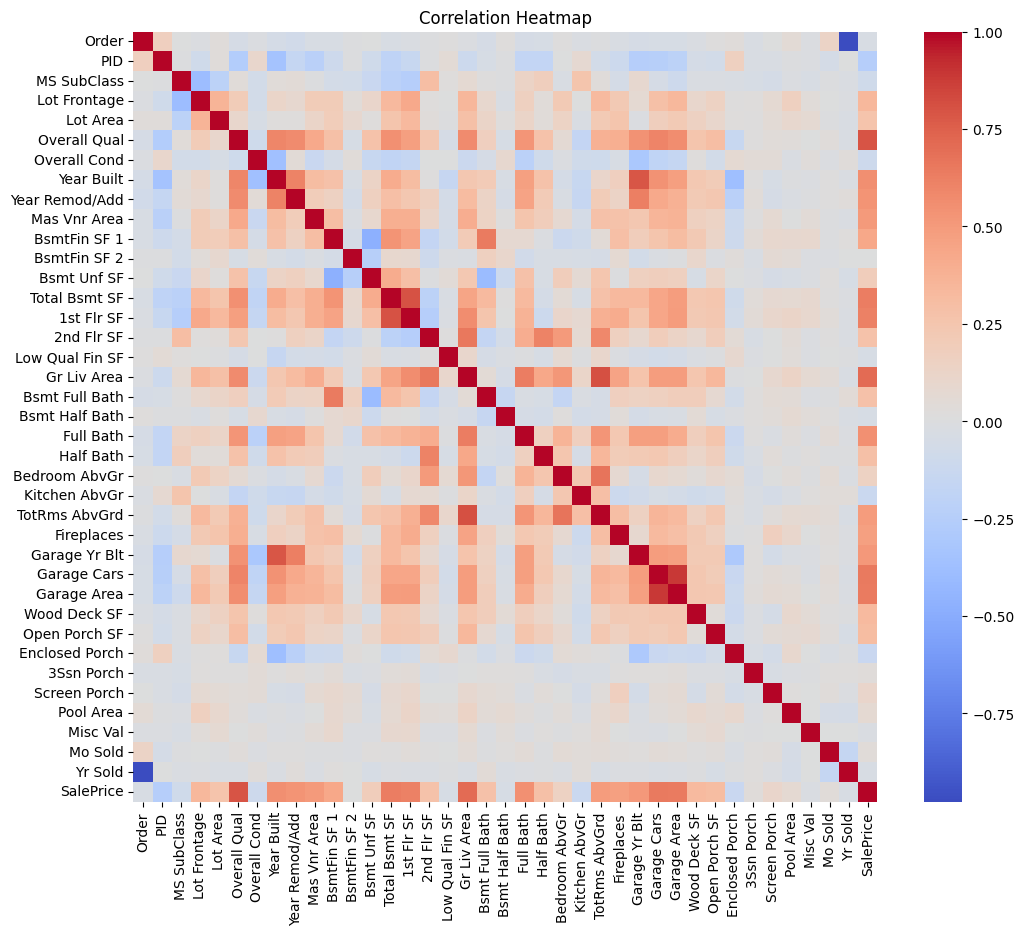

In [20]:
plt.figure(figsize=(12,10))
correlation = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(correlation,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [23]:
df['TotalSF'] = (df['Total Bsmt SF'] +df['1st Flr SF'] +df['2nd Flr SF'])
print(df.TotalSF)

0       2736.0
1       1778.0
2       2658.0
3       4220.0
4       2557.0
         ...  
2925    2006.0
2926    1766.0
2927    1882.0
2928    2778.0
2929    2996.0
Name: TotalSF, Length: 2930, dtype: float64


In [24]:
df['HouseAge'] = (df['Yr Sold'] -df['Year Built'])
print(df.HouseAge)

0       50
1       49
2       52
3       42
4       13
        ..
2925    22
2926    23
2927    14
2928    32
2929    13
Name: HouseAge, Length: 2930, dtype: int64


In [25]:
df['RemodelAge'] = (df['Yr Sold'] -df['Year Remod/Add'])
print(df.RemodelAge)

0       50
1       49
2       52
3       42
4       12
        ..
2925    22
2926    23
2927    14
2928    31
2929    12
Name: RemodelAge, Length: 2930, dtype: int64


In [26]:
df['TotalBathrooms'] = (df['Full Bath'] +(0.5 * df['Half Bath']) +df['Bsmt Full Bath'] +(0.5 * df['Bsmt Half Bath']))
print(df.TotalBathrooms)

0       2.0
1       1.0
2       1.5
3       3.5
4       2.5
       ... 
2925    2.0
2926    2.0
2927    1.5
2928    2.0
2929    2.5
Name: TotalBathrooms, Length: 2930, dtype: float64


In [27]:
df['TotalPorchSF'] = (df['Open Porch SF'] +df['Enclosed Porch'] +df['3Ssn Porch'] +df['Screen Porch'])
print(df.TotalPorchSF)

0        62
1       120
2        36
3         0
4        34
       ... 
2925      0
2926      0
2927     32
2928     38
2929     48
Name: TotalPorchSF, Length: 2930, dtype: int64


In [28]:
df['HasGarage'] = (df['Garage Area'] > 0).astype(int)
print(df.HasGarage)

0       1
1       1
2       1
3       1
4       1
       ..
2925    1
2926    1
2927    0
2928    1
2929    1
Name: HasGarage, Length: 2930, dtype: int64


In [30]:
df['SalePrice_Log'] = np.log1p(df['SalePrice'])
print(df.SalePrice_Log)

0       12.278398
1       11.561725
2       12.055256
3       12.404928
4       12.154258
          ...    
2925    11.867104
2926    11.782960
2927    11.790565
2928    12.043560
2929    12.144203
Name: SalePrice_Log, Length: 2930, dtype: float64


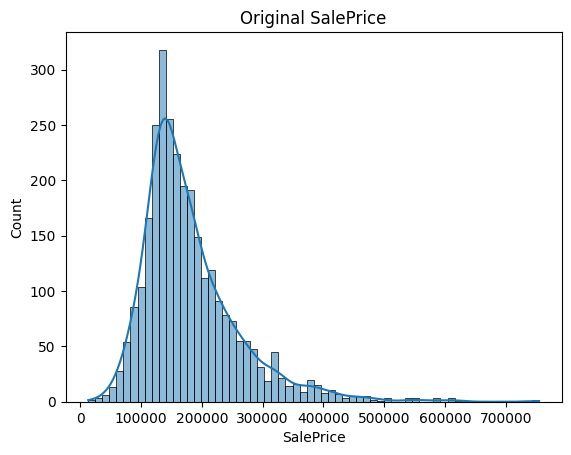

In [31]:
sns.histplot(df['SalePrice'],kde=True)
plt.title("Original SalePrice")
plt.show()

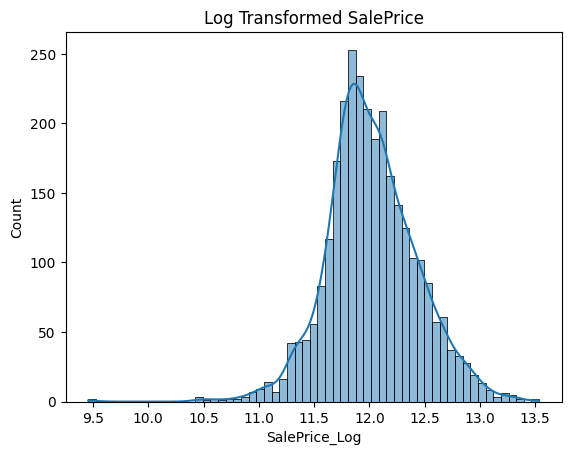

In [33]:
sns.histplot(df['SalePrice_Log'],kde=True)
plt.title("Log Transformed SalePrice")
plt.show()

In [32]:
print(df['SalePrice'].skew())
print(df['SalePrice_Log'].skew())

1.7435000757376466
-0.014772659537224382


In [39]:
X = df.drop(columns=['SalePrice','SalePrice_Log'])
y = df['SalePrice_Log']

In [40]:
X = pd.get_dummies(X,drop_first=True)

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled,y_train)

LinearRegression()

In [44]:
lr_pred = lr_model.predict(X_test_scaled)

In [46]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled,y_train)

Ridge()

In [47]:
ridge_pred = ridge_model.predict(X_test_scaled)

In [48]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [50]:
rf_pred = rf_model.predict(X_test)

In [53]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
lr_mse = mean_squared_error(y_test,lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test,lr_pred)
print("LINEAR REGRESSION")
print("MSE :", lr_mse)
print("RMSE :", lr_rmse)
print("R2 Score :", lr_r2)

LINEAR REGRESSION
MSE : 0.020422495536254456
RMSE : 0.14290729700142837
R2 Score : 0.8896256023598308


In [57]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
ridge_mse = mean_squared_error(y_test,ridge_pred)
ridge_rmse = np.sqrt(lr_mse)
ridge_r2 = r2_score(y_test,ridge_pred)
print("RIDGE REGRESSION")
print("MSE :", ridge_mse)
print("RMSE :", ridge_rmse)
print("R2 Score :", ridge_r2)

RIDGE REGRESSION
MSE : 0.018859078144199078
RMSE : 0.14290729700142837
R2 Score : 0.8980751697793433


In [61]:
rf_mse = mean_squared_error(y_test,rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test,rf_pred)
print("RANDOM FOREST REGRESSION")
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

RANDOM FOREST REGRESSION
MSE : 0.014714627035160964
RMSE : 0.12130386240825543
R2 Score : 0.9204740628968447
